### Step 1 Importing the relevant libraries

In [85]:
import pandas as pd
import numpy as np 



### Step 2 Loading the data

In [86]:
X_train = pd.read_csv("./adult/scaled_data/X_train.csv")
X_test = pd.read_csv("./adult/scaled_data/X_test.csv")
y_train = pd.read_csv("./adult/scaled_data/y_train.csv")
y_test = pd.read_csv("./adult/scaled_data/y_test.csv")

### Step 3 Converting to numpy arrays for the network

In [87]:
X_train_np = X_train.values.astype(np.float64)
X_test_np = X_test.values.astype(np.float64)
y_train_np = y_train.values.reshape(-1, 1).astype(np.float64)
y_test_np = y_test.values.reshape(-1, 1).astype(np.float64)

n_samples, n_features = X_train_np.shape

### Step 4 Define architecture and initialize weights

In [88]:
np.random.seed(42)

n_hidden = 16
n_output = 1 

W1 = np.random.randn(n_features, n_hidden) * np.sqrt(1 / n_features)
b1 = np.zeros((1, n_hidden))

W2 = np.random.randn(n_hidden, n_output) * np.sqrt(1 / n_hidden)
b2 = np.zeros((1, n_output))

### Step 5 Activation functions

In [89]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(a):

    return a * (1 - a)

### Step 6 Forward propagation

In [90]:
def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    return Z1, A1, Z2, A2
    

### Step 7 Loss function( binary cross-entropy)

In [91]:
def compute_loss(y_true, y_pred):
    eps = 1e-8 # to avoid log(0)

    return -np.mean(
        y_true * np.log(y_pred + eps) 
         + (1 - y_true) * np.log(1 - y_pred + eps)
    )

### Step 8 Backpropagation

In [92]:
def backward(X, y, Z1, A1, Z2, A2, W2):
    m = X.shape[0] # count the training examples

    # **** Output layer gradient ***
    # Compute the output later error
    # Measure how far the predictions are frm the true labels
    dZ2 = A2 - y  

    # Calculates how much W2 and b2 should change
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis = 0, keepdims=True) / m

    # Hidden layer gradient
    # Determines how much each hidden neuron contributed to the output error.
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * sigmoid_derivative(A1)
    # Calculates how much W1 and b1 should change.
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis = 0, keepdims=True) / m

    # These gradients are then used in gradient descent to 
    # update the weights and biases.
    return dW1, db1, dW2, db2

### Step 9 Weight updates (gradient descent) and traing loop


In [93]:
learning_rate = 0.1 # Controls the size of each weight update.
epochs = 2000 # Number of times the entire training dataset is processed

losses = [] # Keeps track of the loss at each epoch so it can be displayed later.

for epoch in range(epochs):
    # Computes the network's predictions for the training data.
    Z1, A1, Z2, A2 = forward(X_train_np, W1, b1, W2, b2)
    # Measures how far the predictions are from the true labels.
    loss = compute_loss(y_train_np, A2)
    losses.append(loss)

    # Computes the gradients of the loss with respect to each weight and bias.
    dW1, db1, dW2, db2 = backward(X_train_np, y_train_np, Z1, A1, Z2, A2, W2)

    # Adjusts the weights and biases in the direction that reduces the loss.
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b1 -= learning_rate * db2

    # Displays the loss every 200 epochs to monitor learning.
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {np.mean(loss):.4f}")

    

Epoch 0, Loss: 0.7219
Epoch 200, Loss: 0.4328
Epoch 400, Loss: 0.3729
Epoch 600, Loss: 0.3554
Epoch 800, Loss: 0.3483
Epoch 1000, Loss: 0.3445
Epoch 1200, Loss: 0.3420
Epoch 1400, Loss: 0.3402
Epoch 1600, Loss: 0.3388
Epoch 1800, Loss: 0.3375


### Step 10 Evaluation

In [ ]:
# Imports functions to measure the model's performance.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Runs forward propagation using the trained weights and biases to 
# obtain the predicted probabilities.
_, _, _, A2_test = forward(X_test_np, W1, b1, W2, b2)

# Applies a threshold of 0.5:
    # Probability > 0.5 → Class 1
    # Probability ≤ 0.5 → Class 0
y_pred = (A2_test > 0.5).astype(int)

# Prints the accuracy, i.e., the percentage of correctly classified samples.
print("Accuracy:", accuracy_score(y_test_np, y_pred))
print(confusion_matrix(y_test_np, y_pred))
print(classification_report(y_test_np, y_pred))

Accuracy: 0.8466502765826674
[[4551  389]
 [ 609  959]]
              precision    recall  f1-score   support

         0.0       0.88      0.92      0.90      4940
         1.0       0.71      0.61      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.80      0.77      0.78      6508
weighted avg       0.84      0.85      0.84      6508



### Step 11 Plotting the loss curve

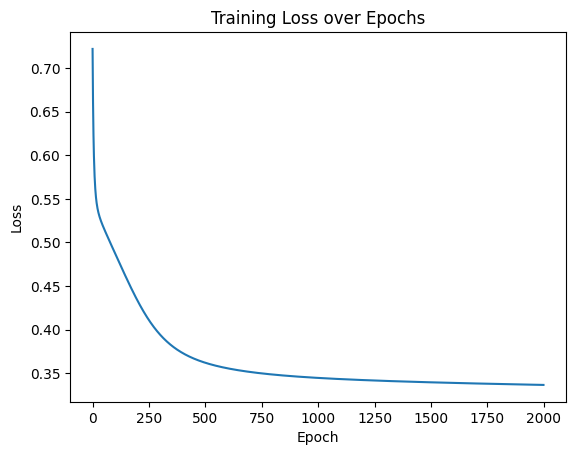

In [95]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.show()